# 01. Exploratory Data Analysis (EDA) - Thailand

**Objective:** Load Thailand macroeconomic data (2006-01 to 2024-01), apply transformations, and generate descriptive statistics & time series visualizations.

**Note:** The monthly GDP series used in this analysis is not directly observed, but is constructed via interpolation following the methodology described in the referenced paper. This approach enables a consistent monthly frequency for all variables, facilitating robust time series modeling and comparison.

## Import libraries

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings

# Set reproducibility & visualization parameters
np.random.seed(42)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (16, 12)
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6f}'.format)

## 1. Load data

In [90]:
# Load Thailand macroeconomic data
df = pd.read_csv("../../data/raw/macro_monthly_15y_tha.csv")

print("THAILAND MACRO DATA OVERVIEW:")
print(f"Shape (rows, columns): {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}\n")
print(f"Missing values per column:\n{df.isnull().sum()}\n")
print("First 5 rows:")
print(df.head())
print("\nColumn data types:")
print(df.dtypes)
print("\nSummary statistics:")
print(df.describe())

THAILAND MACRO DATA OVERVIEW:
Shape (rows, columns): (217, 11)
Columns: ['date', 'country_code', 'country_name', 'GDP_usd', 'CPI_index', 'FX_local_per_USD', 'Exports_usd', 'Imports_usd', 'Trade_balance_usd', 'Interest_rate_percent', 'WTI_usd_per_barrel']
Date range: 2006-01-01 to 2024-01-01

Missing values per column:
date                     0
country_code             0
country_name             0
GDP_usd                  0
CPI_index                0
FX_local_per_USD         0
Exports_usd              0
Imports_usd              0
Trade_balance_usd        0
Interest_rate_percent    0
WTI_usd_per_barrel       0
dtype: int64

First 5 rows:
         date country_code country_name             GDP_usd  CPI_index  \
0  2006-01-01          THA     Thailand 221758296021.621002  90.585459   
1  2006-02-01          THA     Thailand 225190323141.073669  90.754668   
2  2006-03-01          THA     Thailand 228622350260.526306  90.923877   
3  2006-04-01          THA     Thailand 232054377379.979004

## 2. Apply Data Integrity Rule

In [91]:
# Convert date column to datetime and set as index
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# Force monthly frequency
df = df.asfreq('MS')
print("After enforcing monthly frequency:")
print(f"Shape (rows, columns): {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

# Check for missing values after enforcing frequency
print(f"\nMissing values per column after enforcing frequency:\n{df.isnull().sum()}\n")

# Interpolate using linear time-based interpolation
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].interpolate(method='time')

print("Data after interpolation:")
print(f"Missing values per column after interpolation:\n{df.isnull().sum()}\n")
print("First 5 rows after interpolation:")
print(df.head())

After enforcing monthly frequency:
Shape (rows, columns): (217, 10)
Date range: 2006-01-01 00:00:00 to 2024-01-01 00:00:00

Missing values per column after enforcing frequency:
country_code             0
country_name             0
GDP_usd                  0
CPI_index                0
FX_local_per_USD         0
Exports_usd              0
Imports_usd              0
Trade_balance_usd        0
Interest_rate_percent    0
WTI_usd_per_barrel       0
dtype: int64

Data after interpolation:
Missing values per column after interpolation:
country_code             0
country_name             0
GDP_usd                  0
CPI_index                0
FX_local_per_USD         0
Exports_usd              0
Imports_usd              0
Trade_balance_usd        0
Interest_rate_percent    0
WTI_usd_per_barrel       0
dtype: int64

First 5 rows after interpolation:
           country_code country_name             GDP_usd  CPI_index  \
date                                                                  
2006-0

In [92]:
# Data Audit Block
required_cols = ['WTI_usd_per_barrel', 'GDP_usd', 'CPI_index', 'Interest_rate_percent', 'FX_local_per_USD']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print('Missing columns:', missing_cols)

print('Duplicate dates:', df.index.duplicated().sum())
print('Missing values per column:')
print(df[required_cols].isnull().sum())

print('Non-positive values (for log):')
for col in ['WTI_usd_per_barrel', 'GDP_usd', 'CPI_index', 'FX_local_per_USD']:
    n_bad = (df[col] <= 0).sum()
    print(f'{col}: {n_bad}')

expected_months = pd.date_range(df.index.min(), df.index.max(), freq='MS')
if len(df) == len(expected_months) and (df.index == expected_months).all():
    print('Monthly continuity: OK')
else:
    print(f'Monthly continuity issue: expected {len(expected_months)}, got {len(df)}')

Duplicate dates: 0
Missing values per column:
WTI_usd_per_barrel       0
GDP_usd                  0
CPI_index                0
Interest_rate_percent    0
FX_local_per_USD         0
dtype: int64
Non-positive values (for log):
WTI_usd_per_barrel: 0
GDP_usd: 0
CPI_index: 0
FX_local_per_USD: 0
Monthly continuity: OK


In [98]:
df_master = df.reset_index()[[
    "date", "country_code", "country_name",
    "GDP_usd", "CPI_index", "FX_local_per_USD",
    "Interest_rate_percent", "WTI_usd_per_barrel"
]].copy()

df_master.to_csv("../../data/processed/THA_master_monthly.csv", index=False)
print("Saved THA_master_monthly.csv")

Saved THA_master_monthly.csv


## 3. Apply Variable Mapping (Log Transformations)

In [93]:
mapping = {
    'WTI_usd_per_barrel': 'ln_WTI',
    'GDP_usd': 'ln_GDP',
    'CPI_index': 'ln_CPI',
    'Interest_rate_percent': 'Interest',  # NO LOG
    'FX_local_per_USD': 'ln_FX'
}

# Apply log transformation to all columns except interest rate
for col in df.columns:
    if col in mapping and mapping[col] != 'Interest':
        df[mapping[col]] = np.log(df[col])
    elif col in mapping:
        df[mapping[col]] = df[col]

# Select only the transformed columns for analysis
svar_vars = ['ln_WTI', 'ln_GDP', 'ln_CPI', 'Interest', 'ln_FX']
df_svar = df[svar_vars].copy()

print("Data after log transformation:")
print(df_svar.head())
print("\nSummary statistics after log transformation:")
print(df_svar.describe())

Data after log transformation:
             ln_WTI    ln_GDP   ln_CPI  Interest    ln_FX
date                                                     
2006-01-01 4.181821 26.124854 4.506294  6.273807 3.634476
2006-02-01 4.121166 26.140212 4.508160  6.254871 3.627048
2006-03-01 4.138126 26.155337 4.510023  6.235934 3.619566
2006-04-01 4.240516 26.170238 4.511882  6.216998 3.612026
2006-05-01 4.260482 26.184919 4.513738  6.198061 3.604430

Summary statistics after log transformation:
          ln_WTI     ln_GDP     ln_CPI   Interest      ln_FX
count 217.000000 217.000000 217.000000 217.000000 217.000000
mean    4.231815  26.726899   4.678495   4.563532   3.497605
std     0.330147   0.238056   0.075335   0.828061   0.051493
min     2.806242  26.124854   4.506294   3.060000   3.417456
25%     4.003798  26.598089   4.624035   4.125833   3.446401
50%     4.270790  26.746088   4.706031   4.534228   3.504380
75%     4.493400  26.943559   4.724459   5.077546   3.541486
max     4.896944  27.022172  

## 4. Descriptive Statistics

In [94]:
# Calculate comprehensive statistics
stats_df = pd.DataFrame({
    'Mean': df_svar.mean(),
    'Median': df_svar.median(),
    'Std Dev': df_svar.std(),
    'Min': df_svar.min(),
    'Max': df_svar.max(),
    'Skewness': df_svar.skew(),
    'Kurtosis': df_svar.kurtosis(),
    'Count': df_svar.count()
})

print(stats_df.to_string())

# Additional statistics
for col in df_svar.columns:
    print(f"\n{col}:")
    print(f"25th percentile: {df_svar[col].quantile(0.25):.6f}")
    print(f"75th percentile: {df_svar[col].quantile(0.75):.6f}")
    print(f"IQR: {df_svar[col].quantile(0.75) - df_svar[col].quantile(0.25):.6f}")
    print(f"Missing values: {df_svar[col].isnull().sum()}")

# Export statistics to CSV for reference
stats_df.to_csv(r'../../outputs/THA/descriptive_stats_tha.csv')

              Mean    Median  Std Dev       Min       Max  Skewness  Kurtosis  Count
ln_WTI    4.231815  4.270790 0.330147  2.806242  4.896944 -0.660585  0.785777    217
ln_GDP   26.726899 26.746088 0.238056 26.124854 27.022172 -0.750805 -0.495227    217
ln_CPI    4.678495  4.706031 0.075335  4.506294  4.812175 -0.648804 -0.355120    217
Interest  4.563532  4.534228 0.828061  3.060000  6.273807  0.027993 -0.410199    217
ln_FX     3.497605  3.504380 0.051493  3.417456  3.634476  0.165501 -0.996390    217

ln_WTI:
25th percentile: 4.003798
75th percentile: 4.493400
IQR: 0.489602
Missing values: 0

ln_GDP:
25th percentile: 26.598089
75th percentile: 26.943559
IQR: 0.345470
Missing values: 0

ln_CPI:
25th percentile: 4.624035
75th percentile: 4.724459
IQR: 0.100424
Missing values: 0

Interest:
25th percentile: 4.125833
75th percentile: 5.077546
IQR: 0.951713
Missing values: 0

ln_FX:
25th percentile: 3.446401
75th percentile: 3.541486
IQR: 0.095086
Missing values: 0


## 5. Time Series Visualizations

Saved: ../../outputs/THA/timeseries_plots_tha.png


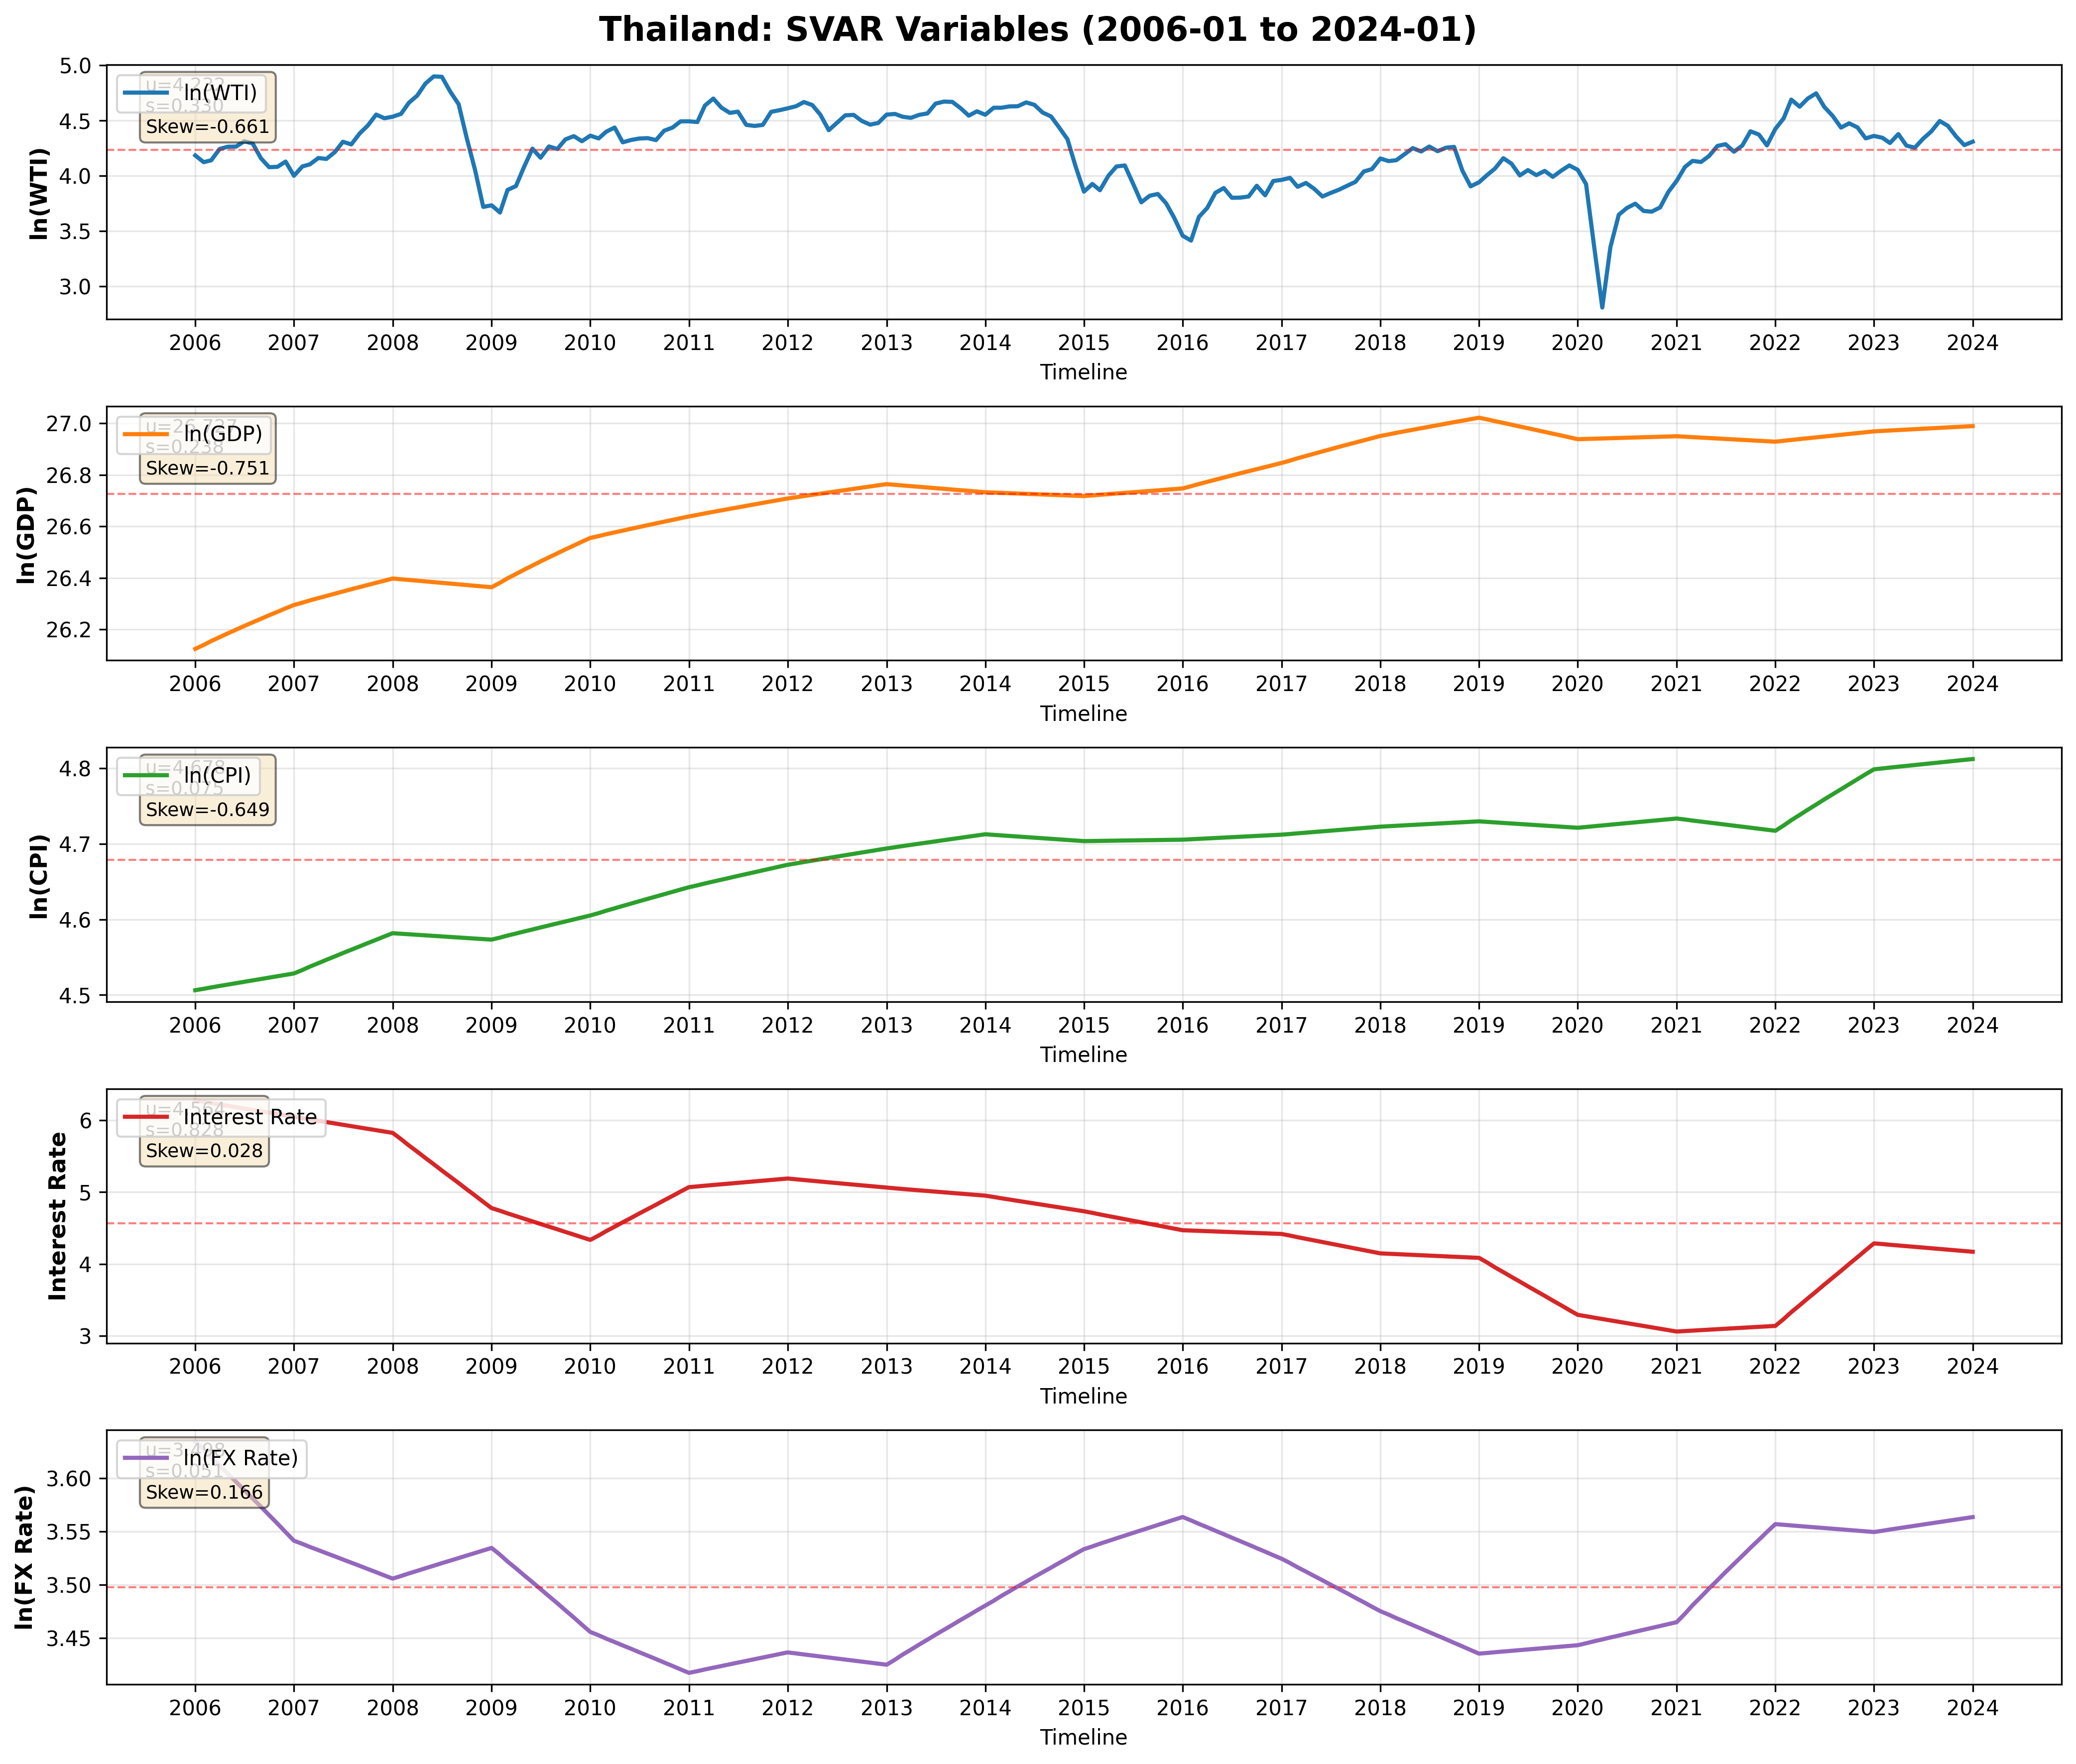


Dataset Summary:
  - Observations: 217
  - Variables: 5
  - Missing values: 0


In [95]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12))
fig.suptitle('Thailand: SVAR Variables (2006-01 to 2024-01)', fontsize=16, fontweight='bold')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
variable_labels = ['ln(WTI)', 'ln(GDP)', 'ln(CPI)', 'Interest Rate', 'ln(FX Rate)']

for idx, (col, label, color) in enumerate(zip(df_svar.columns, variable_labels, colors)):
    ax = axes[idx]
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.plot(df_svar.index, df_svar[col], linewidth=2, color=color, label=label)

    # Formatting
    ax.set_ylabel(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Timeline', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=10)

    # Add data range on plot
    mean_val = df_svar[col].mean()
    ax.axhline(y=mean_val, color='red', linestyle='--', alpha=0.5, linewidth=1, label=f'Mean: {mean_val:.3f}')

    # Statistics box
    stats_text = f"u={df_svar[col].mean():.3f}\ns={df_svar[col].std():.3f}\nSkew={df_svar[col].skew():.3f}"
    ax.text(0.02, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(r'../../outputs/THA/timeseries_plots_tha.png', dpi=300, bbox_inches='tight')
print("Saved: ../../outputs/THA/timeseries_plots_tha.png")
plt.show()

print(f"\nDataset Summary:")
print(f"  - Observations: {len(df_svar)}")
print(f"  - Variables: {len(df_svar.columns)}")
print(f"  - Missing values: {df_svar.isnull().sum().sum()}")

The figure shows that `ln_WTI` is the most volatile variable in the system, reflecting major external oil price shocks over the sample period, particularly around 2008–2009 and 2020. In contrast, `ln_GDP` and `ln_CPI` display relatively smooth upward trends, which is consistent with the long-run behavior of macroeconomic variables, while `Interest` and `ln_FX` fluctuate more moderately. Overall, the series appear to contain trend components, so formal stationarity tests are required before proceeding to SVAR estimation.

In [99]:
df_svar.to_csv("../../data/processed/THA_model_ready.csv", index=True)
print("Saved THA_model_ready.csv")

Saved THA_model_ready.csv
